# 1. Import librerías

In [1]:
import json

import soundfile as sf
import numpy as np
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann
from scipy.interpolate import interp1d
from plotly.express.colors import qualitative
import plotly.graph_objects as go
import plotly.express as px
from skimage.transform import resize
import matplotlib.pyplot as plt
import tifffile


colors = qualitative.Plotly

# 2. Cargar señal

In [3]:
file = "3875"
wav_file = fr"dataset\audio\{file}.wav"

signal, fs = sf.read(wav_file)
t = np.arange(len(signal)) / fs

In [4]:
fig = px.line(x=t, y=signal, labels={"x": "Time (s)", "y": "Amplitude"}, title=f"Respiratory sound signal")
fig.update_layout(
    hovermode="x unified",
    template="plotly_white"
)
fig.show()

# 3. Representaciones Tiempo-Frecuencia

## 3.1. Espectrograma - STFT

In [ ]:
# Generación espectrograma
N = len(signal)
Nw = 179
NFFT = 2048
stft = ShortTimeFFT(hann(Nw), 1, fs, mfft=NFFT, scale_to="psd")

f = stft.f

spectrogram = stft.spectrogram(signal)
print(spectrogram.shape)

S_dB_lin = 10*np.log10(spectrogram + 1e-14)  # Convertir a dB

# Cortar espectrograma
mask = (f >= 50) & (f <= 2000)
f_masked = f[mask]

fig = go.Figure(
    go.Heatmap(x=t, y=f_masked, z=S_dB_lin[mask], colorbar=dict(title="PSD (dB/Hz)"), colorscale="magma")
)

fig.update_layout(
    height=500, width=500,
    title="Spectrogram",
    xaxis_title="Time (s)",
    yaxis_title="Frequency (Hz)",
    yaxis=dict(type="log"),
    template="plotly_white",
)

fig.show()

(1025, 37270)


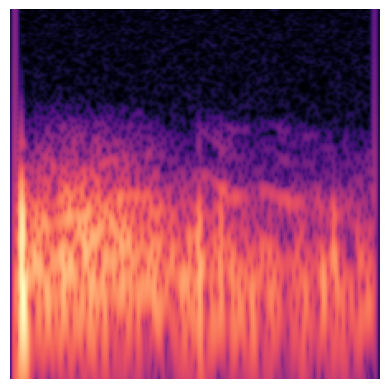

In [ ]:
# Escala de frecuencia logarítmica
f_log = np.geomspace(f_masked.min(), f_masked.max(), len(f_masked))
S_log = interp1d(f_masked, S_dB_lin[mask], axis=0, kind="linear")(f_log)
# Reshape
S_resized = np.flipud(resize(S_log, (224, 224)))

plt.imshow(S_resized, cmap="magma")
plt.axis("off")
plt.show()

In [ ]:
# tifffile.imwrite("spectrogram.tiff", S_resized.astype(np.float32))

In [ ]:
# loaded = tifffile.imread("spectrogram.tiff")
# plt.imshow(S_resized, cmap="gray")
# plt.axis("off")
# plt.show()